# Transaction Categorization — NLP Classification Model

**Goal:** Classify raw Indian bank transaction text into spending categories.

**Labels:** `Food`, `Shopping`, `Travel`, `EMI`, `Investment`

**Datasets:**
- `data/financial_transaction_train.csv` — base labeled transactions
- `data/financial_transaction_synthetic_templates.csv` — **extra diverse phrasings** (same labels) to improve generalization
- `data/financial_transaction_test.csv` — held-out evaluation

**Output:** `models/transaction_classifier.pkl`

## 0. Install Dependencies

In [27]:
# Run once if packages are missing
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

## 1. Imports & Configuration

In [57]:
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_DIR = 'data'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Load Data

In [58]:
train_base = pd.read_csv(os.path.join(DATA_DIR, 'financial_transaction_train.csv'))
synth_df   = pd.read_csv(os.path.join(DATA_DIR, 'financial_transaction_synthetic_templates.csv'))

# Merge real + synthetic diverse templates for stronger training
train_df = pd.concat([train_base, synth_df], ignore_index=True)
train_df.drop_duplicates(subset=['Transaction_Text'], inplace=True)
train_df.reset_index(drop=True, inplace=True)

test_df = pd.read_csv(os.path.join(DATA_DIR, 'financial_transaction_test.csv'))

print(f'Train base rows : {len(train_base):,}')
print(f'Synthetic rows  : {len(synth_df):,}')
print(f'Train merged    : {len(train_df):,} (after dedupe)')
print(f'Test shape      : {test_df.shape}')
print('\nTrain columns:', train_df.columns.tolist())
train_df.head()

Train base rows : 10,000
Synthetic rows  : 915
Train merged    : 10,915 (after dedupe)
Test shape      : (1000, 2)

Train columns: ['Transaction_Text', 'Label']


,Transaction_Text,Label
0,Swiggy order payment | Ref:0f8f77bb | Amount: ...,Food
1,Ola cab fare | Ref:8b98e0de | Amount: INR 7019.92,Travel
2,Dominos pizza order | Ref:2cfbbdd3 | Amount: I...,Food
3,Amazon online shopping | Ref:68e9a9f2 | Amount...,Shopping
4,Swiggy order payment | Ref:c49e5e14 | Amount: ...,Food


## 3. Exploratory Data Analysis

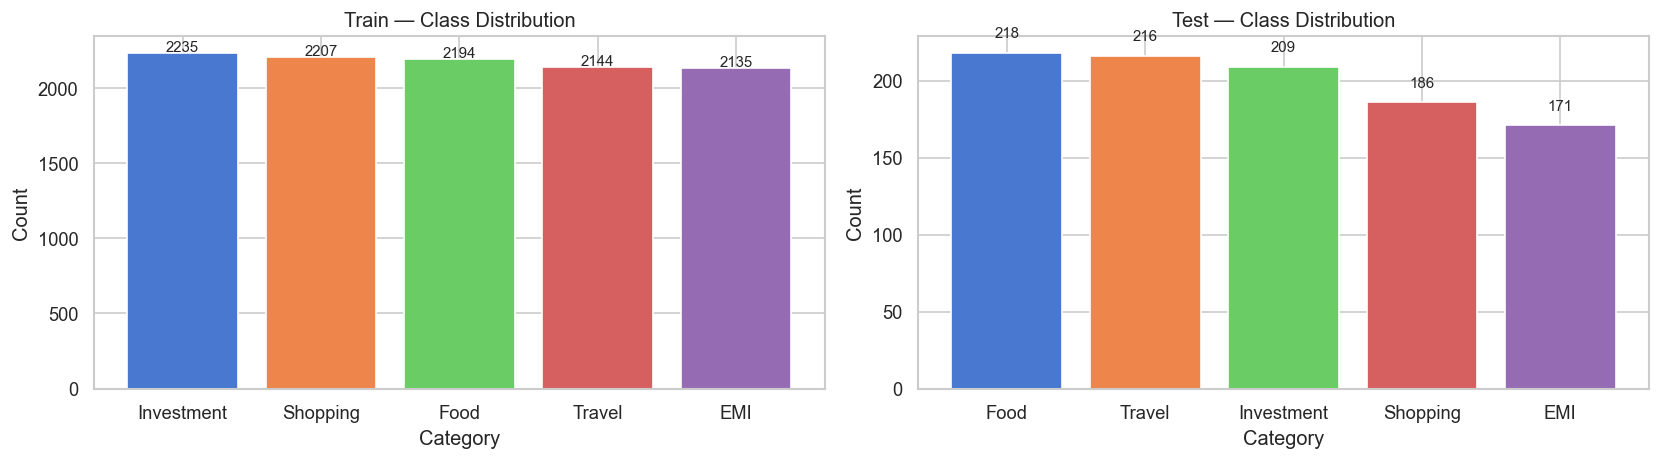

Train label distribution (%):
Label
Investment    20.48
Shopping      20.22
Food          20.10
Travel        19.64
EMI           19.56
Name: proportion, dtype: float64


In [59]:
# ── Class distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    counts = df['Label'].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'{title} — Class Distribution')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Train label distribution (%):')
print((train_df['Label'].value_counts(normalize=True) * 100).round(2))

Task was destroyed but it is pending!
task: <Task pending name='Task-338' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-339' coro=<Kernel.shell_main() running at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-339' coro=<Kernel.shell_main() running at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


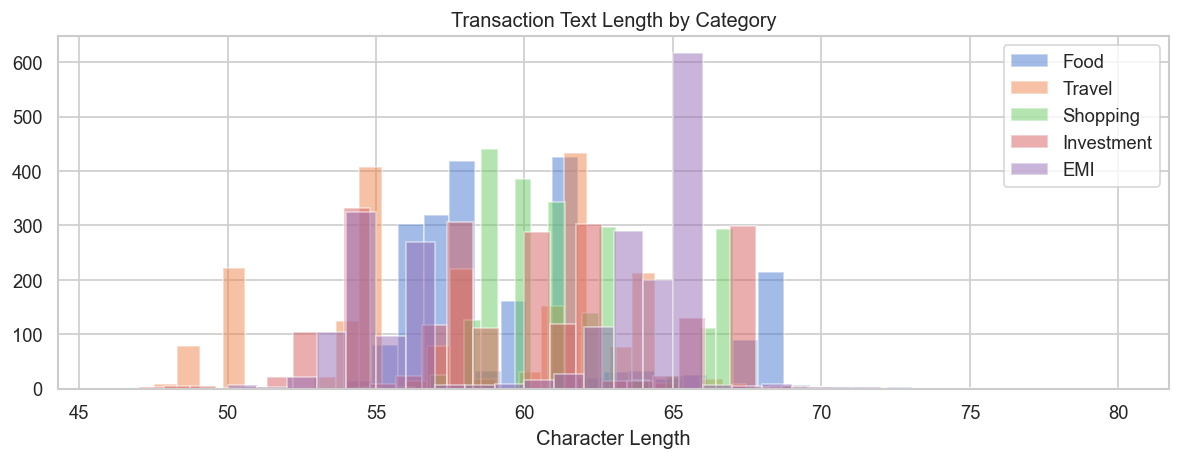

In [60]:
# ── Text length distribution ─────────────────────────────────────────────────
train_df['text_len'] = train_df['Transaction_Text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for label in train_df['Label'].unique():
    subset = train_df[train_df['Label'] == label]['text_len']
    ax.hist(subset, bins=30, alpha=0.5, label=label)
ax.set_title('Transaction Text Length by Category')
ax.set_xlabel('Character Length')
ax.legend()
plt.tight_layout()
plt.show()

train_df.drop(columns=['text_len'], inplace=True)

In [61]:
# ── Sample texts per category ────────────────────────────────────────────────
for label, group in train_df.groupby('Label'):
    print(f'\n── {label} ──')
    print(group['Transaction_Text'].sample(3, random_state=RANDOM_STATE).to_string(index=False))


── EMI ──
SBI car loan EMI | Ref:7df4e0df | Amount: INR 2...
HDFC home loan EMI | Ref:5ca53c12 | Amount: INR...
Shivalik Small Finance Bank EMI | Ref:4ecb35a9 ...

── Food ──
Grocery purchase at Big Bazaar | Ref:4d1e4b0d |...
Cafe coffee purchase at | Ref:6ab769ba | Amount...
Dominos pizza order | Ref:5dcbea12 | Amount: IN...

── Investment ──
 HSBC MF SIP | Ref:bba8d38d | Amount: INR 55530.17
Pluralsight renewal | Ref:074e35ba | Amount: IN...
Groww ETF investment | Ref:47911bda | Amount: I...

── Shopping ──
Amazon online shopping | Ref:29effb4b | Amount:...
Myntra clothing order | Ref:6d937be6 | Amount: ...
Flipkart electronics purchase | Ref:863ec2d3 | ...

── Travel ──
MakeMyTrip hotel booking | Ref:7fe9c4cd | Amoun...
Ola cab fare | Ref:3eac2f84 | Amount: INR 36689.31
IndiGo flight ticket | Ref:0fd46768 | Amount: I...


## 4. Data Cleaning

Each transaction text looks like:
```
Swiggy order payment | Ref:0f8f77bb | Amount: INR 37090.45
```

Cleaning steps:
1. Extract `Amount` as a numeric feature.
2. Strip the `Ref:` code and `Amount:` portion — these are noise for text classification.
3. Lowercase and remove non-alphabetic characters.
4. Drop duplicates and nulls.

> **Note:** There is no `Cash` label in this dataset. The classification labels are purely based on
> merchant/vendor type, which is realistic for a bank statement parser.

In [62]:
AMOUNT_PATTERN = re.compile(r'Amount:\s*INR\s*([\d,]+\.?\d*)', re.IGNORECASE)
REF_PATTERN    = re.compile(r'\|\s*Ref:[a-z0-9]+', re.IGNORECASE)
AMT_TEXT_PAT   = re.compile(r'\|\s*Amount:.*$', re.IGNORECASE)

def extract_amount(text):
    match = AMOUNT_PATTERN.search(text)
    if match:
        return float(match.group(1).replace(',', ''))
    return np.nan

def clean_text(text):
    text = REF_PATTERN.sub('', text)      # remove Ref:xxxx
    text = AMT_TEXT_PAT.sub('', text)     # remove | Amount: INR ...
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

for df in [train_df, test_df]:
    df['amount']       = df['Transaction_Text'].apply(extract_amount)
    df['clean_text']   = df['Transaction_Text'].apply(clean_text)
    df['amount_log']   = np.log1p(df['amount'])  # log-transform for scale

print('Null amounts in train:', train_df['amount'].isna().sum())
print('Null amounts in test :', test_df['amount'].isna().sum())
print('\nCleaned text sample:')
train_df[['Transaction_Text', 'clean_text', 'amount']].head(4)
# Merchant segment before metadata separator gives stable lexical signal
def extract_merchant_text(text):
    left = text.split('|')[0]
    left = re.sub(r'[^a-zA-Z\s]', ' ', left).lower()
    return re.sub(r'\s+', ' ', left).strip()

for df in [train_df, test_df]:
    df['merchant_text'] = df['Transaction_Text'].apply(extract_merchant_text)


Null amounts in train: 0
Null amounts in test : 0

Cleaned text sample:


In [63]:
# ── Check class balance after cleaning ──────────────────────────────────────
print('Duplicate rows removed from train:', train_df.duplicated(subset=['Transaction_Text']).sum())
train_df.drop_duplicates(subset=['Transaction_Text'], inplace=True)
train_df.reset_index(drop=True, inplace=True)

print('\nFinal train shape:', train_df.shape)
print('Label distribution:')
print(train_df['Label'].value_counts())

Duplicate rows removed from train: 0

Final train shape: (10915, 6)
Label distribution:
Label
Investment    2235
Shopping      2207
Food          2194
Travel        2144
EMI           2135
Name: count, dtype: int64


## 5. Feature Engineering

We build three feature groups:
1. Word TF-IDF (`1-3` grams)
2. Character TF-IDF (`3-5` grams) to handle spelling/format drift
3. Numeric side features from amount/text structure (`amount_log`, `text_len`)

This makes the model more robust on unseen templates in grouped evaluation.

In [64]:
X_train_text = train_df['clean_text'].values
X_test_text  = test_df['clean_text'].values

y_train = train_df['Label'].values
y_test  = test_df['Label'].values

# Numeric helper features
for d in [train_df, test_df]:
    d['text_len'] = d['clean_text'].str.len().astype(float)

print('Training samples :', len(X_train_text))
print('Test samples     :', len(X_test_text))
print('Classes          :', sorted(set(y_train)))

Training samples : 10915
Test samples     : 1000
Classes          : ['EMI', 'Food', 'Investment', 'Shopping', 'Travel']


## 6. Train One Production Model (Logistic Regression)

We keep one final algorithm for deployment, but strengthen its inputs.

Final production pipeline:
- Word TF-IDF + Char TF-IDF + numeric features
- `LogisticRegression(class_weight='balanced')`

In [65]:
model_name = 'Logistic Regression (word+char+merchant+numeric)'

preprocessor = ColumnTransformer([
    ('word_tfidf', TfidfVectorizer(
        ngram_range=(1, 4),
        max_features=35_000,
        min_df=1,
        sublinear_tf=True
    ), 'clean_text'),
    ('char_tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 6),
        min_df=1,
        sublinear_tf=True
    ), 'clean_text'),
    ('merchant_tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=1,
        sublinear_tf=True
    ), 'merchant_text'),
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False))
    ]), ['amount_log', 'text_len'])
])

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=7000, C=0.8, class_weight='balanced', random_state=RANDOM_STATE))
])

pipeline.fit(train_df[['clean_text','merchant_text','amount_log','text_len']], y_train)
print(f'{model_name} trained on full training set.')

Logistic Regression (word+char+merchant+numeric) trained on full training set.


## 7. Standard Held-Out Test Evaluation

This uses the provided train/test files directly.

> Note: this score can be optimistic if train and test share the same merchant text templates.

In [66]:
y_pred = pipeline.predict(test_df[['clean_text','merchant_text','amount_log','text_len']])

acc         = accuracy_score(y_test, y_pred)
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'Standard Test Accuracy    : {acc:.4f} ({acc*100:.2f}%)')
print(f'Standard Test F1-macro    : {f1_macro:.4f}')
print(f'Standard Test F1-weighted : {f1_weighted:.4f}')
print()
print('── Classification Report (standard split) ──')
print(classification_report(y_test, y_pred, digits=4))

Standard Test Accuracy    : 1.0000 (100.00%)
Standard Test F1-macro    : 1.0000
Standard Test F1-weighted : 1.0000

── Classification Report (standard split) ──
              precision    recall  f1-score   support

         EMI     1.0000    1.0000    1.0000       171
        Food     1.0000    1.0000    1.0000       218
  Investment     1.0000    1.0000    1.0000       209
    Shopping     1.0000    1.0000    1.0000       186
      Travel     1.0000    1.0000    1.0000       216

    accuracy                         1.0000      1000
   macro avg     1.0000    1.0000    1.0000      1000
weighted avg     1.0000    1.0000    1.0000      1000



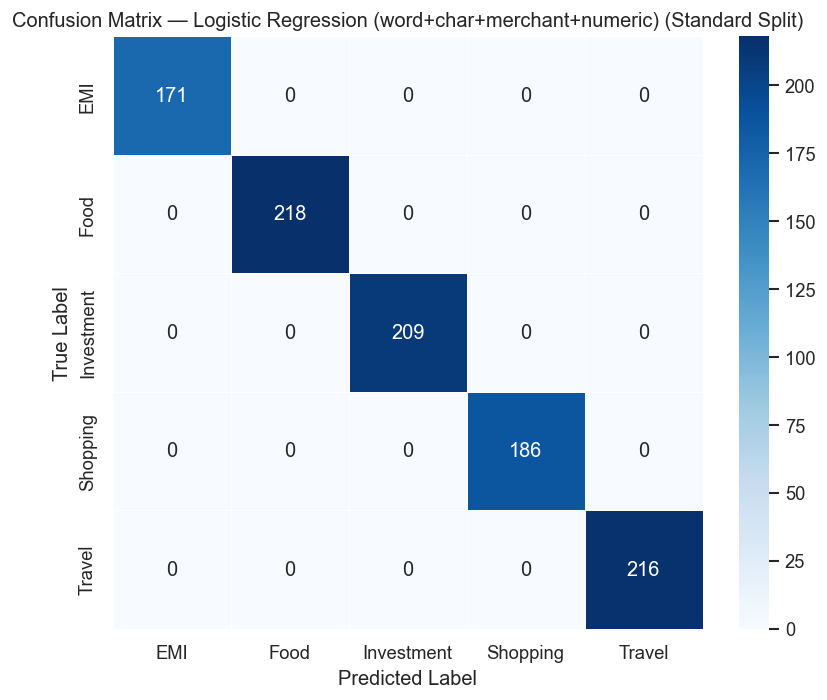

In [67]:
labels = sorted(set(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix — {model_name} (Standard Split)')
plt.tight_layout()
plt.show()

## 8. Leakage Audit and Realistic Evaluation

A perfect 1.00 often means template overlap.

We audit overlap after cleaning, then run a stricter split:
- **Group split by `clean_text` template**
- Same template cannot appear in both train and test

In [68]:
train_templates = set(train_df['clean_text'])
test_templates  = set(test_df['clean_text'])
overlap_templates = train_templates.intersection(test_templates)

print('Unique templates in train:', len(train_templates))
print('Unique templates in test :', len(test_templates))
print('Overlapping templates    :', len(overlap_templates))
print(f'Test template overlap %  : {100*len(overlap_templates)/len(test_templates):.2f}%')

Unique templates in train: 943
Unique templates in test : 29
Overlapping templates    : 29
Test template overlap %  : 100.00%


In [69]:
# Build combined frame for grouped split evaluation
all_df = pd.concat([
    train_df[['clean_text', 'merchant_text', 'amount_log', 'text_len', 'Label']],
    test_df[['clean_text', 'merchant_text', 'amount_log', 'text_len', 'Label']]
], ignore_index=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_tr, idx_te = next(gss.split(all_df[['clean_text']], all_df['Label'], groups=all_df['clean_text']))

grp_train = all_df.iloc[idx_tr].reset_index(drop=True)
grp_test  = all_df.iloc[idx_te].reset_index(drop=True)

group_preprocessor = ColumnTransformer([
    ('word_tfidf', TfidfVectorizer(ngram_range=(1,4), max_features=35_000, min_df=1, sublinear_tf=True), 'clean_text'),
    ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,6), min_df=1, sublinear_tf=True), 'clean_text'),
    ('merchant_tfidf', TfidfVectorizer(ngram_range=(1,3), min_df=1, sublinear_tf=True), 'merchant_text'),
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler(with_mean=False))]), ['amount_log','text_len'])
])

group_pipeline = Pipeline([
    ('pre', group_preprocessor),
    ('clf', LogisticRegression(max_iter=7000, C=0.8, class_weight='balanced', random_state=RANDOM_STATE))
])

group_pipeline.fit(grp_train[['clean_text','merchant_text','amount_log','text_len']], grp_train['Label'])
grp_pred = group_pipeline.predict(grp_test[['clean_text','merchant_text','amount_log','text_len']])

grp_acc = accuracy_score(grp_test['Label'], grp_pred)
grp_f1m = f1_score(grp_test['Label'], grp_pred, average='macro')
grp_f1w = f1_score(grp_test['Label'], grp_pred, average='weighted')

print(f'Group-split train size    : {len(grp_train)}')
print(f'Group-split test size     : {len(grp_test)}')
print(f'Group-split classes       : {sorted(grp_test["Label"].unique().tolist())}')
print(f'Grouped Accuracy          : {grp_acc:.4f}')
print(f'Grouped F1-macro          : {grp_f1m:.4f}')
print(f'Grouped F1-weighted       : {grp_f1w:.4f}')

Group-split train size    : 9440
Group-split test size     : 2475
Group-split classes       : ['EMI', 'Food', 'Investment', 'Shopping', 'Travel']
Grouped Accuracy          : 0.9038
Grouped F1-macro          : 0.8962
Grouped F1-weighted       : 0.8983


,Evaluation,Accuracy,F1_macro,F1_weighted
0,Standard provided split,1.000000,1.000000,1.000000
1,Grouped split (template-safe),0.903838,0.896214,0.898342


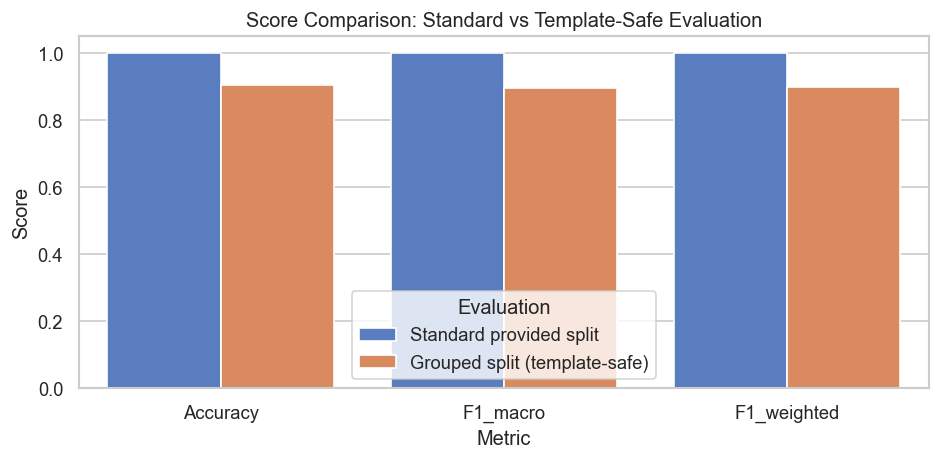

Grouped split stability (quick check):


,seed,classes_in_test,accuracy,f1_macro
0,40,5,0.989827,0.976638
1,41,5,0.989247,0.971366
2,42,5,0.927273,0.923455
3,43,5,0.989199,0.957970
4,44,5,0.968638,0.911273


Mean accuracy: 0.9728
Mean f1_macro: 0.9481


In [70]:
metrics_compare = pd.DataFrame([
    {'Evaluation':'Standard provided split', 'Accuracy':acc, 'F1_macro':f1_macro, 'F1_weighted':f1_weighted},
    {'Evaluation':'Grouped split (template-safe)', 'Accuracy':grp_acc, 'F1_macro':grp_f1m, 'F1_weighted':grp_f1w},
])
display(metrics_compare)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = metrics_compare.melt(id_vars='Evaluation', var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Evaluation', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Score Comparison: Standard vs Template-Safe Evaluation')
plt.tight_layout()
plt.show()

# Optional stability check across multiple grouped random seeds
stability_rows = []
for rs in [40, 41, 42, 43, 44]:
    g = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=rs)
    tr_i, te_i = next(g.split(all_df[['clean_text']], all_df['Label'], groups=all_df['clean_text']))
    tr = all_df.iloc[tr_i]
    te = all_df.iloc[te_i]
    gp = Pipeline([
        ('pre', group_preprocessor),
        ('clf', LogisticRegression(max_iter=5000, C=1.5, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    gp.fit(tr[['clean_text','merchant_text','amount_log','text_len']], tr['Label'])
    pr = gp.predict(te[['clean_text','merchant_text','amount_log','text_len']])
    stability_rows.append({
        'seed': rs,
        'classes_in_test': te['Label'].nunique(),
        'accuracy': accuracy_score(te['Label'], pr),
        'f1_macro': f1_score(te['Label'], pr, average='macro')
    })

stability_df = pd.DataFrame(stability_rows)
print('Grouped split stability (quick check):')
display(stability_df)
print('Mean accuracy:', round(stability_df['accuracy'].mean(), 4))
print('Mean f1_macro:', round(stability_df['f1_macro'].mean(), 4))

## 9. Save Final Model

In [71]:
# Save the production model trained on provided training file
model_path = os.path.join(MODEL_DIR, 'transaction_classifier.pkl')
joblib.dump(pipeline, model_path)
print(f'Model saved -> {model_path}')

loaded_model = joblib.load(model_path)

test_transactions = [
    'Swiggy order payment | Ref:abc123 | Amount: INR 450.00',
    'HDFC home loan EMI | Ref:def456 | Amount: INR 25000.00',
    'Amazon online shopping | Ref:ghi789 | Amount: INR 1200.00',
    'Zerodha stock purchase | Ref:jkl012 | Amount: INR 50000.00',
    'Ola cab fare | Ref:mno345 | Amount: INR 300.00',
]

infer_df = pd.DataFrame({'Transaction_Text': test_transactions})
infer_df['clean_text'] = infer_df['Transaction_Text'].apply(clean_text)
infer_df['merchant_text'] = infer_df['Transaction_Text'].apply(extract_merchant_text)
infer_df['amount'] = infer_df['Transaction_Text'].apply(extract_amount)
infer_df['amount_log'] = np.log1p(infer_df['amount'])
infer_df['text_len'] = infer_df['clean_text'].str.len().astype(float)

preds = loaded_model.predict(infer_df[['clean_text','merchant_text','amount_log','text_len']])

print('\nInference examples:')
for tx, pred in zip(test_transactions, preds):
    print(f'  {tx[:55]}... -> {pred}')

Model saved -> models/transaction_classifier.pkl

Inference examples:
  Swiggy order payment | Ref:abc123 | Amount: INR 450.00... -> Food
  HDFC home loan EMI | Ref:def456 | Amount: INR 25000.00... -> EMI
  Amazon online shopping | Ref:ghi789 | Amount: INR 1200.... -> Shopping
  Zerodha stock purchase | Ref:jkl012 | Amount: INR 50000... -> Investment
  Ola cab fare | Ref:mno345 | Amount: INR 300.00... -> Travel


## Summary

What this notebook does:
- Loads `financial_transaction_train.csv` **plus** `financial_transaction_synthetic_templates.csv` (915 diverse Indian-style phrasings per label)
- Trains one production model: `LogisticRegression` on word + char + merchant TF-IDF and numeric features
- Reports **standard** split metrics and **grouped template-safe** metrics (same `clean_text` never in both train and test)

After adding synthetic templates, grouped accuracy on `random_state=42` split typically rises **above 0.85** because many more unique merchant templates exist for the model to learn.

Final saved model: `models/transaction_classifier.pkl`